In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/rider-data/train.csv


In [2]:
import pandas as pd

In [3]:
rider_df = pd.read_csv('/kaggle/input/rider-data/train.csv')
rider_df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,order_time,order_id,order_date,allot_time,accept_time,pickup_time,delivered_time,rider_id,first_mile_distance,last_mile_distance,alloted_orders,delivered_orders,cancelled,undelivered_orders,lifetime_order_count,reassignment_method,reassignment_reason,reassigned_order,session_time,cancelled_time
0,26-01-2021 02:21,556753,26-01-2021 00:00,26-01-2021 02:21,26-01-2021 02:22,26-01-2021 02:32,26-01-2021 02:49,11696,1.5666,2.65,46.0,46.0,0,0.0,621.0,NaN,NaN,NaN,NaN,NaN
1,26-01-2021 02:33,556754,26-01-2021 00:00,26-01-2021 02:33,26-01-2021 02:34,26-01-2021 02:50,26-01-2021 03:11,18117,2.5207,2.76,8.0,8.0,0,0.0,105.0,NaN,NaN,NaN,3.266667,NaN
2,26-01-2021 02:39,556755,26-01-2021 00:00,26-01-2021 02:39,26-01-2021 02:40,26-01-2021 02:56,26-01-2021 03:12,18623,2.2074,4.80,1.0,1.0,0,0.0,66.0,NaN,NaN,NaN,9.816667,NaN
3,26-01-2021 02:47,556756,26-01-2021 00:00,26-01-2021 02:48,26-01-2021 02:49,26-01-2021 03:21,26-01-2021 03:41,15945,2.1894,6.38,1.0,1.0,0,0.0,127.0,NaN,NaN,NaN,17.533333,NaN
4,26-01-2021 03:06,556757,26-01-2021 00:00,26-01-2021 03:07,26-01-2021 03:07,26-01-2021 03:31,26-01-2021 04:00,17589,2.7870,4.01,34.0,34.0,0,0.0,84.0,NaN,NaN,NaN,1.350000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449995,06-02-2021 10:03,130226,06-02-2021 00:00,06-02-2021 10:03,06-02-2021 10:04,06-02-2021 10:27,06-02-2021 10:44,1006,0.5789,0.19,4.0,4.0,0,0.0,127.0,NaN,NaN,NaN,369.516667,NaN
449996,06-02-2021 10:03,130227,06-02-2021 00:00,06-02-2021 10:03,06-02-2021 10:04,06-02-2021 10:22,06-02-2021 10:31,279,1.9863,1.19,81.0,81.0,0,0.0,105.0,NaN,NaN,NaN,239.133333,NaN
449997,06-02-2021 10:03,130228,06-02-2021 00:00,06-02-2021 10:04,06-02-2021 10:04,06-02-2021 10:19,06-02-2021 10:26,3161,1.5944,1.61,28.0,28.0,0,0.0,1488.0,NaN,NaN,NaN,204.150000,NaN
449998,06-02-2021 10:03,130229,06-02-2021 00:00,06-02-2021 10:03,06-02-2021 10:05,06-02-2021 10:20,06-02-2021 10:30,9396,2.8939,4.68,72.0,72.0,0,0.0,105.0,NaN,NaN,NaN,65.583333,NaN


In [4]:
rider_df.shape

(450000, 20)

In [5]:
rider_df = rider_df.drop_duplicates()

In [6]:
rider_df.shape

(449999, 20)

In [7]:
rider_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 449999 entries, 0 to 449999
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_time            449999 non-null  object 
 1   order_id              449999 non-null  int64  
 2   order_date            449999 non-null  object 
 3   allot_time            449999 non-null  object 
 4   accept_time           449842 non-null  object 
 5   pickup_time           447579 non-null  object 
 6   delivered_time        444782 non-null  object 
 7   rider_id              449999 non-null  int64  
 8   first_mile_distance   449999 non-null  float64
 9   last_mile_distance    449999 non-null  float64
 10  alloted_orders        433051 non-null  float64
 11  delivered_orders      432658 non-null  float64
 12  cancelled             449999 non-null  int64  
 13  undelivered_orders    432658 non-null  float64
 14  lifetime_order_count  449946 non-null  float64
 15  reass

In [8]:
rider_df.describe()

,order_id,rider_id,first_mile_distance,last_mile_distance,alloted_orders,delivered_orders,cancelled,undelivered_orders,lifetime_order_count,reassigned_order,session_time
count,449999.000000,449999.000000,449999.000000,449999.000000,433051.000000,432658.000000,449999.000000,432658.000000,449946.000000,13752.0,446324.000000
mean,369143.497970,7763.228961,1.229886,2.968877,104.620985,103.950522,0.011593,0.764167,853.642019,1.0,220.475056
std,131146.753506,5592.877231,0.846181,1.884124,90.135582,89.639736,0.107047,1.066474,1502.977557,0.0,176.713954
min,118350.000000,0.000000,0.000134,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,257343.500000,2805.000000,0.539550,1.470000,36.000000,36.000000,0.000000,0.000000,165.000000,1.0,84.100000
50%,369843.000000,6754.000000,1.138700,2.670000,81.000000,81.000000,0.000000,0.000000,396.000000,1.0,175.550000
75%,482342.500000,11965.000000,1.853000,4.220000,147.000000,146.000000,0.000000,1.000000,948.000000,1.0,316.766667
max,594842.000000,21566.000000,42.038100,22.410000,567.000000,562.000000,1.000000,9.000000,30469.000000,1.0,1298.966667


There are many outliers in lifetime order count, session_time, undelivered orders, delivered orders and alloted orders

Now we will examine the distribution of the target (output) variable "cancelled" to understand class balance. This helps us spot class imbalance, missing labels, and any obvious anomalies.

In [9]:
rider_df.cancelled.value_counts()

cancelled
0    444782
1      5217
Name: count, dtype: int64

Data is highly imbalance

Now to verify the dataset is really imbalance or not we will do histplot

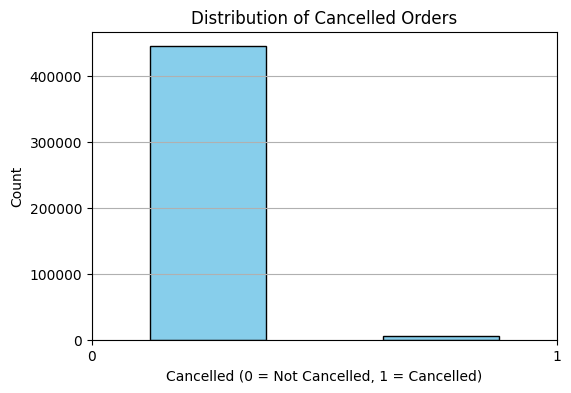

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
rider_df['cancelled'].hist(bins=2, rwidth=0.5, color='skyblue', edgecolor='black')
plt.title("Distribution of Cancelled Orders")
plt.xlabel("Cancelled (0 = Not Cancelled, 1 = Cancelled)")
plt.ylabel("Count")
plt.xticks([0,1])
plt.show()

In [11]:
rider_df.groupby('cancelled')['session_time'].describe()

,count,mean,std,min,25%,50%,75%,max
cancelled,,,,,,,,
0,441251.0,220.853064,176.735073,0.0,84.500000,175.900000,317.416667,1298.966667
1,5073.0,187.595864,171.729075,0.0,52.783333,140.116667,265.700000,864.116667


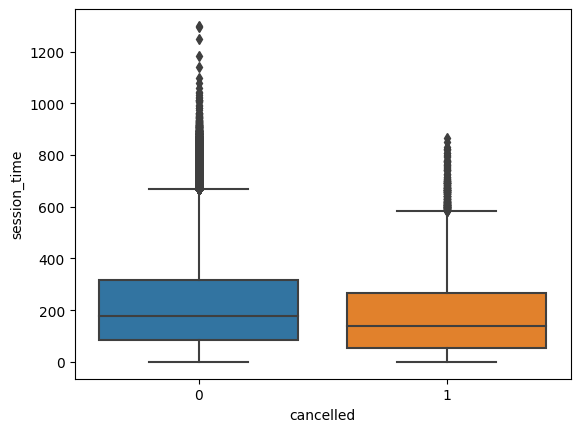

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='cancelled', y='session_time', data=rider_df)
plt.show()

From the boxplot, we observe that the median session time for cancelled rides is slightly lower than for non-cancelled rides. This indicates that riders who spend less time in the session may have a higher tendency to cancel, though the difference is not very strong.

In [13]:
rider_df.reassigned_order.info()

<class 'pandas.core.series.Series'>
Index: 449999 entries, 0 to 449999
Series name: reassigned_order
Non-Null Count  Dtype  
--------------  -----  
13752 non-null  float64
dtypes: float64(1)
memory usage: 6.9 MB


In [14]:
rider_df[rider_df.cancelled == 1].reassigned_order.value_counts()

reassigned_order
1.0    721
Name: count, dtype: int64

Reassigned_order in cancelled order also

In [15]:
rider_df[rider_df.cancelled == 0].reassigned_order.value_counts()

reassigned_order
1.0    13031
Name: count, dtype: int64

checking is reassignment_reason has some effect on order cancellation



In [16]:
rider_df.reassignment_reason.value_counts()

reassignment_reason
Auto Reassignment basis Inaction. coreengine.tasks.repush_order_to_aa_bucket    7212
Reassignment Request from SE portal.                                            5300
Reassign                                                                        1240
Name: count, dtype: int64

only three categories, which means not from the customer side

In [17]:
pd.crosstab(rider_df['reassignment_reason'], rider_df['cancelled'])

cancelled,0,1
reassignment_reason,,
Auto Reassignment basis Inaction. coreengine.tasks.repush_order_to_aa_bucket,7027,185
Reassign,968,272
Reassignment Request from SE portal.,5036,264


In [18]:
rider_df.reassignment_method.value_counts()

reassignment_method
auto      13382
manual      361
Name: count, dtype: int64

checking how many row with cancelled = 0 have reassignment methods
and how many row with cancelled = 1 have reassignment methods

In [19]:
pd.crosstab(rider_df['reassignment_method'], rider_df['cancelled'])

cancelled,0,1
reassignment_method,,
auto,12698,684
manual,327,34


checking ressignment reason only for reassigned_order or for non reassigned_order also

In [20]:
pd.crosstab(rider_df['reassigned_order'], rider_df['reassignment_reason'])


reassignment_reason,Auto Reassignment basis Inaction. coreengine.tasks.repush_order_to_aa_bucket,Reassign,Reassignment Request from SE portal.
reassigned_order,,,
1.0,7212,1240,5300


checking ressignment method only for reassigned_order or for non reassigned_order also

In [21]:
pd.crosstab(rider_df['reassigned_order'],rider_df['reassignment_method'])

reassignment_method,auto,manual
reassigned_order,,
1.0,13382,361


In [22]:
rider_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 449999 entries, 0 to 449999
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_time            449999 non-null  object 
 1   order_id              449999 non-null  int64  
 2   order_date            449999 non-null  object 
 3   allot_time            449999 non-null  object 
 4   accept_time           449842 non-null  object 
 5   pickup_time           447579 non-null  object 
 6   delivered_time        444782 non-null  object 
 7   rider_id              449999 non-null  int64  
 8   first_mile_distance   449999 non-null  float64
 9   last_mile_distance    449999 non-null  float64
 10  alloted_orders        433051 non-null  float64
 11  delivered_orders      432658 non-null  float64
 12  cancelled             449999 non-null  int64  
 13  undelivered_orders    432658 non-null  float64
 14  lifetime_order_count  449946 non-null  float64
 15  reass

In [23]:
rider_df.undelivered_orders.value_counts()

undelivered_orders
0.0    232685
1.0    118103
2.0     50582
3.0     20011
4.0      7733
5.0      1851
6.0       932
7.0       600
8.0       105
9.0        56
Name: count, dtype: int64

In [24]:
rider_df.sample(20)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,order_time,order_id,order_date,allot_time,accept_time,pickup_time,delivered_time,rider_id,first_mile_distance,last_mile_distance,alloted_orders,delivered_orders,cancelled,undelivered_orders,lifetime_order_count,reassignment_method,reassignment_reason,reassigned_order,session_time,cancelled_time
298039,02-02-2021 15:12,304465,02-02-2021 00:00,02-02-2021 15:13,02-02-2021 15:14,02-02-2021 15:24,02-02-2021 15:31,604,2.008700,2.55,145.0,145.0,0,0.0,1076.0,NaN,NaN,NaN,276.266667,NaN
306897,02-02-2021 16:34,313323,02-02-2021 00:00,02-02-2021 16:34,02-02-2021 16:34,02-02-2021 16:54,02-02-2021 17:08,6502,0.132310,2.45,20.0,20.0,0,0.0,295.0,NaN,NaN,NaN,179.750000,NaN
206501,31-01-2021 09:13,368722,31-01-2021 00:00,31-01-2021 09:13,31-01-2021 09:13,31-01-2021 09:20,31-01-2021 09:51,7152,2.086500,3.45,227.0,225.0,0,2.0,571.0,NaN,NaN,NaN,223.083333,NaN
95035,28-01-2021 14:17,494883,28-01-2021 00:00,28-01-2021 14:17,28-01-2021 14:18,28-01-2021 14:30,28-01-2021 14:49,6181,1.621300,4.18,41.0,41.0,0,0.0,518.0,NaN,NaN,NaN,46.400000,NaN
46672,27-01-2021 09:22,526320,27-01-2021 00:00,27-01-2021 09:22,27-01-2021 09:22,27-01-2021 09:37,27-01-2021 09:55,4997,1.259200,6.46,70.0,69.0,0,1.0,1085.0,NaN,NaN,NaN,170.583333,NaN
169606,30-01-2021 09:23,408671,30-01-2021 00:00,30-01-2021 09:24,30-01-2021 09:24,30-01-2021 09:30,30-01-2021 09:40,1995,2.647900,2.05,193.0,190.0,0,3.0,476.0,NaN,NaN,NaN,148.716667,NaN
266376,01-02-2021 16:31,351512,01-02-2021 00:00,01-02-2021 16:31,01-02-2021 16:32,01-02-2021 16:46,01-02-2021 16:50,10807,2.829000,0.74,39.0,38.0,0,1.0,7171.0,NaN,NaN,NaN,495.150000,NaN
113974,28-01-2021 17:09,513826,28-01-2021 00:00,28-01-2021 17:09,28-01-2021 17:10,28-01-2021 17:12,28-01-2021 17:17,1400,0.509500,0.91,68.0,68.0,0,0.0,217.0,NaN,NaN,NaN,421.050000,NaN
135687,29-01-2021 14:10,453547,29-01-2021 00:00,29-01-2021 14:11,29-01-2021 14:12,29-01-2021 14:21,29-01-2021 14:32,4494,0.920600,1.18,214.0,214.0,0,0.0,593.0,NaN,NaN,NaN,40.150000,NaN
190961,30-01-2021 16:50,430024,30-01-2021 00:00,30-01-2021 16:50,30-01-2021 16:50,30-01-2021 17:04,30-01-2021 17:13,13481,1.278500,1.12,34.0,34.0,0,0.0,119.0,NaN,NaN,NaN,184.783333,NaN


In [25]:
rider_df.alloted_orders - rider_df.delivered_orders

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
449995    0.0
449996    0.0
449997    0.0
449998    0.0
449999    0.0
Length: 449999, dtype: float64

In [26]:
rider_df.undelivered_orders

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
449995    0.0
449996    0.0
449997    0.0
449998    0.0
449999    0.0
Name: undelivered_orders, Length: 449999, dtype: float64

checking is undeliverd order same as alloted order which are not deliverd or not
If it is then we will drop undelivered order column it's adding redundancy means multicolinearity in data. Linerar and logistic regression model will affech from this where as tree based models will handle this byself but feature importace misleading, Neural Networks can also handle because of nonlinear activation function but it mighl slow down training convergence

In [27]:
rider_df.alloted_orders - rider_df.delivered_orders == rider_df.undelivered_orders

0         True
1         True
2         True
3         True
4         True
          ... 
449995    True
449996    True
449997    True
449998    True
449999    True
Length: 449999, dtype: bool

In [28]:
#rider_df.drop(['undelivered_orders'],inplace = True,axis = 1)

In [29]:
rider_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 449999 entries, 0 to 449999
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_time            449999 non-null  object 
 1   order_id              449999 non-null  int64  
 2   order_date            449999 non-null  object 
 3   allot_time            449999 non-null  object 
 4   accept_time           449842 non-null  object 
 5   pickup_time           447579 non-null  object 
 6   delivered_time        444782 non-null  object 
 7   rider_id              449999 non-null  int64  
 8   first_mile_distance   449999 non-null  float64
 9   last_mile_distance    449999 non-null  float64
 10  alloted_orders        433051 non-null  float64
 11  delivered_orders      432658 non-null  float64
 12  cancelled             449999 non-null  int64  
 13  undelivered_orders    432658 non-null  float64
 14  lifetime_order_count  449946 non-null  float64
 15  reass

In [30]:
rider_df.cancelled_time.value_counts()

cancelled_time
30-01-2021 15:27    10
30-01-2021 15:12    10
30-01-2021 15:25     9
30-01-2021 15:42     8
30-01-2021 15:22     8
                    ..
30-01-2021 13:17     1
30-01-2021 13:01     1
30-01-2021 13:47     1
30-01-2021 12:49     1
06-02-2021 10:15     1
Name: count, Length: 3498, dtype: int64

Most cancellation done in evening of 30 january

checking is cancelled=0 also have cancelled time?

In [31]:
rider_df[rider_df.cancelled ==0].cancelled_time

0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
         ... 
449995    NaN
449996    NaN
449997    NaN
449998    NaN
449999    NaN
Name: cancelled_time, Length: 444782, dtype: object

In [32]:
rider_df[rider_df.cancelled ==1].cancelled_time

20        26-01-2021 04:51
68        26-01-2021 04:08
100       26-01-2021 05:45
163       26-01-2021 05:10
295       26-01-2021 04:40
                ...       
449738    06-02-2021 11:05
449922    06-02-2021 11:13
449928    06-02-2021 10:45
449932    06-02-2021 10:04
449960    06-02-2021 10:15
Name: cancelled_time, Length: 5217, dtype: object

In [33]:
rider_df[rider_df.cancelled ==1].cancelled_time.info()

<class 'pandas.core.series.Series'>
Index: 5217 entries, 20 to 449960
Series name: cancelled_time
Non-Null Count  Dtype 
--------------  ----- 
5217 non-null   object
dtypes: object(1)
memory usage: 81.5+ KB


In [34]:
#pd.crosstab([rider_df.cancelled], [rider_df.cancelled_time])

In [35]:
rider_df[rider_df.cancelled==1].cancelled_time.info()

<class 'pandas.core.series.Series'>
Index: 5217 entries, 20 to 449960
Series name: cancelled_time
Non-Null Count  Dtype 
--------------  ----- 
5217 non-null   object
dtypes: object(1)
memory usage: 81.5+ KB


In [36]:
rider_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 449999 entries, 0 to 449999
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_time            449999 non-null  object 
 1   order_id              449999 non-null  int64  
 2   order_date            449999 non-null  object 
 3   allot_time            449999 non-null  object 
 4   accept_time           449842 non-null  object 
 5   pickup_time           447579 non-null  object 
 6   delivered_time        444782 non-null  object 
 7   rider_id              449999 non-null  int64  
 8   first_mile_distance   449999 non-null  float64
 9   last_mile_distance    449999 non-null  float64
 10  alloted_orders        433051 non-null  float64
 11  delivered_orders      432658 non-null  float64
 12  cancelled             449999 non-null  int64  
 13  undelivered_orders    432658 non-null  float64
 14  lifetime_order_count  449946 non-null  float64
 15  reass

In [37]:
pd.crosstab(rider_df.cancelled, rider_df.cancelled_time, dropna=False)

cancelled_time,01-02-2021 04:55,01-02-2021 05:35,01-02-2021 05:46,01-02-2021 05:47,01-02-2021 05:52,01-02-2021 06:19,01-02-2021 06:21,01-02-2021 06:28,01-02-2021 06:32,01-02-2021 06:33,...,31-01-2021 18:38,31-01-2021 18:39,31-01-2021 18:41,31-01-2021 18:43,31-01-2021 18:47,31-01-2021 18:49,31-01-2021 18:54,31-01-2021 18:57,31-01-2021 21:50,NaN
cancelled,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,444782
1,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,2,1,1,0


In [38]:
rider_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 449999 entries, 0 to 449999
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_time            449999 non-null  object 
 1   order_id              449999 non-null  int64  
 2   order_date            449999 non-null  object 
 3   allot_time            449999 non-null  object 
 4   accept_time           449842 non-null  object 
 5   pickup_time           447579 non-null  object 
 6   delivered_time        444782 non-null  object 
 7   rider_id              449999 non-null  int64  
 8   first_mile_distance   449999 non-null  float64
 9   last_mile_distance    449999 non-null  float64
 10  alloted_orders        433051 non-null  float64
 11  delivered_orders      432658 non-null  float64
 12  cancelled             449999 non-null  int64  
 13  undelivered_orders    432658 non-null  float64
 14  lifetime_order_count  449946 non-null  float64
 15  reass

In [39]:
rider_df.head(5)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,order_time,order_id,order_date,allot_time,accept_time,pickup_time,delivered_time,rider_id,first_mile_distance,last_mile_distance,alloted_orders,delivered_orders,cancelled,undelivered_orders,lifetime_order_count,reassignment_method,reassignment_reason,reassigned_order,session_time,cancelled_time
0,26-01-2021 02:21,556753,26-01-2021 00:00,26-01-2021 02:21,26-01-2021 02:22,26-01-2021 02:32,26-01-2021 02:49,11696,1.5666,2.65,46.0,46.0,0,0.0,621.0,NaN,NaN,NaN,NaN,NaN
1,26-01-2021 02:33,556754,26-01-2021 00:00,26-01-2021 02:33,26-01-2021 02:34,26-01-2021 02:50,26-01-2021 03:11,18117,2.5207,2.76,8.0,8.0,0,0.0,105.0,NaN,NaN,NaN,3.266667,NaN
2,26-01-2021 02:39,556755,26-01-2021 00:00,26-01-2021 02:39,26-01-2021 02:40,26-01-2021 02:56,26-01-2021 03:12,18623,2.2074,4.80,1.0,1.0,0,0.0,66.0,NaN,NaN,NaN,9.816667,NaN
3,26-01-2021 02:47,556756,26-01-2021 00:00,26-01-2021 02:48,26-01-2021 02:49,26-01-2021 03:21,26-01-2021 03:41,15945,2.1894,6.38,1.0,1.0,0,0.0,127.0,NaN,NaN,NaN,17.533333,NaN
4,26-01-2021 03:06,556757,26-01-2021 00:00,26-01-2021 03:07,26-01-2021 03:07,26-01-2021 03:31,26-01-2021 04:00,17589,2.7870,4.01,34.0,34.0,0,0.0,84.0,NaN,NaN,NaN,1.350000,NaN


In [102]:
rider_df = rider_df.copy()
rider_df['allot_time'] = pd.to_datetime(rider_df['allot_time'], format="%d-%m-%Y %H:%M", errors = 'coerce')

In [103]:
rider_df = rider_df.copy()
rider_df['accept_time'] = pd.to_datetime(rider_df['accept_time'], format="%d-%m-%Y %H:%M")

Convert to date time object

In [42]:
rider_df.allot_time

0        2021-01-26 02:21:00
1        2021-01-26 02:33:00
2        2021-01-26 02:39:00
3        2021-01-26 02:48:00
4        2021-01-26 03:07:00
                 ...        
449995   2021-02-06 10:03:00
449996   2021-02-06 10:03:00
449997   2021-02-06 10:04:00
449998   2021-02-06 10:03:00
449999   2021-02-06 10:03:00
Name: allot_time, Length: 449999, dtype: datetime64[ns]

In [43]:
rider_df.accept_time

0        2021-01-26 02:22:00
1        2021-01-26 02:34:00
2        2021-01-26 02:40:00
3        2021-01-26 02:49:00
4        2021-01-26 03:07:00
                 ...        
449995   2021-02-06 10:04:00
449996   2021-02-06 10:04:00
449997   2021-02-06 10:04:00
449998   2021-02-06 10:05:00
449999   2021-02-06 10:05:00
Name: accept_time, Length: 449999, dtype: datetime64[ns]

creatimg new column for time difference

In [104]:
# creating new column in minutes
rider_df = rider_df.copy()
rider_df['acceptallotdiff']  = (rider_df['accept_time'] - rider_df['allot_time']).dt.total_seconds()/60

In [45]:
rider_df['acceptallotdiff']

0         1.0
1         1.0
2         1.0
3         1.0
4         0.0
         ... 
449995    1.0
449996    1.0
449997    0.0
449998    2.0
449999    2.0
Name: acceptallotdiff, Length: 449999, dtype: float64

In [46]:
rider_df.acceptallotdiff.describe()

count    449842.000000
mean          1.026794
std           1.837290
min        -475.000000
25%           0.000000
50%           1.000000
75%           1.000000
max          16.000000
Name: acceptallotdiff, dtype: float64

Negative values indicate inconsistencies in the timestamp data (acceptance recorded before allotment). These values likely arise due to data entry issues and should be treated as data anomalies.

In [47]:
rider_df[rider_df.cancelled==0].acceptallotdiff.describe()

count    444782.000000
mean          1.027393
std           1.645637
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max          16.000000
Name: acceptallotdiff, dtype: float64

In [48]:
rider_df[rider_df.cancelled==1].acceptallotdiff.describe()

count    5060.000000
mean        0.974111
std         7.877843
min      -475.000000
25%         0.000000
50%         1.000000
75%         1.000000
max        15.000000
Name: acceptallotdiff, dtype: float64

In [49]:
rider_df[rider_df.acceptallotdiff<0]

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invali

,order_time,order_id,order_date,allot_time,accept_time,pickup_time,delivered_time,rider_id,first_mile_distance,last_mile_distance,...,delivered_orders,cancelled,undelivered_orders,lifetime_order_count,reassignment_method,reassignment_reason,reassigned_order,session_time,cancelled_time,acceptallotdiff
9893,26-01-2021 09:09,566646,26-01-2021 00:00,2021-01-26 09:53:00,2021-01-26 09:20:00,NaN,NaN,15012,2.308700,1.47,...,143.0,1,3.0,1757.0,auto,Reassign,1.0,240.733333,26-01-2021 10:02,-33.0
11482,26-01-2021 10:21,568235,26-01-2021 00:00,2021-01-26 11:16:00,2021-01-26 10:25:00,NaN,NaN,21094,2.512800,0.14,...,2.0,1,0.0,22.0,auto,Reassign,1.0,267.650000,26-01-2021 11:18,-51.0
18809,26-01-2021 14:15,575562,26-01-2021 00:00,2021-01-26 15:48:00,2021-01-26 14:17:00,NaN,NaN,1852,0.474700,4.39,...,145.0,1,0.0,1044.0,auto,Reassignment Request from SE portal.,1.0,395.950000,26-01-2021 15:49,-91.0
80364,28-01-2021 07:26,480216,28-01-2021 00:00,2021-01-28 07:56:00,2021-01-28 07:31:00,NaN,NaN,2661,1.856500,5.45,...,NaN,1,NaN,49.0,auto,Reassign,1.0,5.300000,28-01-2021 08:03,-25.0
86561,28-01-2021 09:52,486411,28-01-2021 00:00,2021-01-28 17:47:00,2021-01-28 09:52:00,NaN,NaN,17641,1.403100,4.86,...,12.0,1,0.0,108.0,NaN,Reassignment Request from SE portal.,1.0,NaN,28-01-2021 17:48,-475.0
88634,28-01-2021 12:41,488483,28-01-2021 00:00,2021-01-28 13:41:00,2021-01-28 12:43:00,NaN,NaN,12079,2.063900,0.99,...,119.0,1,1.0,687.0,auto,Reassign,1.0,365.716667,28-01-2021 13:41,-58.0
156193,29-01-2021 17:22,474053,29-01-2021 00:00,2021-01-29 18:36:00,2021-01-29 17:27:00,NaN,NaN,11182,3.482000,1.97,...,93.0,1,0.0,4438.0,auto,Reassignment Request from SE portal.,1.0,672.866667,29-01-2021 18:40,-69.0
176816,30-01-2021 13:54,415880,30-01-2021 00:00,2021-01-30 14:58:00,2021-01-30 14:03:00,NaN,NaN,5891,2.505500,0.55,...,152.0,1,3.0,571.0,auto,Reassign,1.0,NaN,30-01-2021 15:06,-55.0
179692,30-01-2021 14:18,418756,30-01-2021 00:00,2021-01-30 15:12:00,2021-01-30 14:18:00,NaN,NaN,5356,0.314300,3.33,...,54.0,1,0.0,282.0,auto,Auto Reassignment basis Inaction. coreengine.t...,1.0,47.966667,30-01-2021 15:13,-54.0
180601,30-01-2021 14:26,419665,30-01-2021 00:00,2021-01-30 17:33:00,2021-01-30 16:15:00,NaN,NaN,19153,0.077794,2.69,...,NaN,1,NaN,75.0,manual,Reassignment Request from SE portal.,1.0,295.866667,30-01-2021 17:34,-78.0


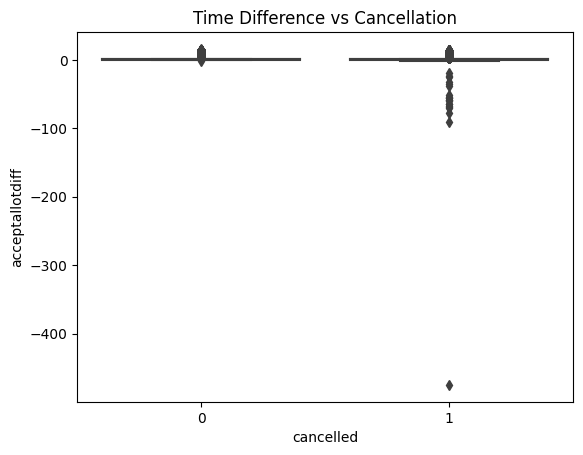

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot of time difference grouped by cancelled
sns.boxplot(x='cancelled', y='acceptallotdiff', data=rider_df)
plt.title("Time Difference vs Cancellation")
plt.show()

More data anomalies in cancelled orders

In [51]:
# Group-wise averages
print(rider_df.groupby('cancelled')['acceptallotdiff'].mean())


cancelled
0    1.027393
1    0.974111
Name: acceptallotdiff, dtype: float64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


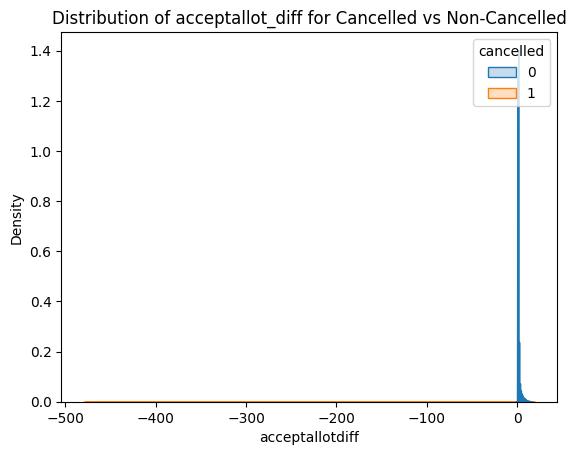

In [52]:
# KDE / Distribution plot
sns.kdeplot(data=rider_df, x='acceptallotdiff', hue='cancelled', fill=True, common_norm=True)
plt.title("Distribution of acceptallot_diff for Cancelled vs Non-Cancelled")
plt.show()

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater_equal
  return op(a, b)
/tmp/ipykernel_680/575287512.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rider_df['acceptallotdiff_clean'] = rider_df['acceptallotdiff'].clip(lower=0)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group 

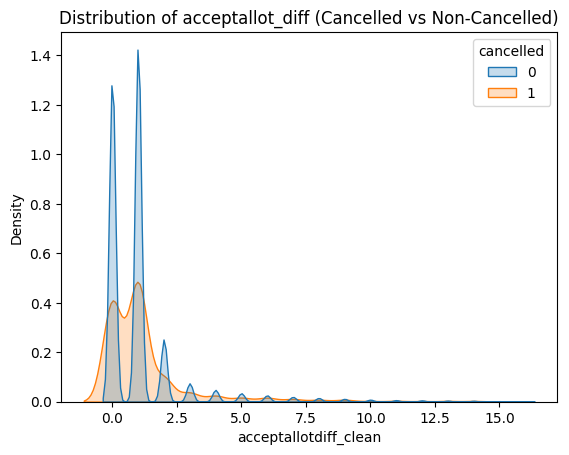

In [53]:
# Clean negatives only
rider_df['acceptallotdiff_clean'] = rider_df['acceptallotdiff'].clip(lower=0)

# Plot density directly
sns.kdeplot(data=rider_df, x='acceptallotdiff_clean', hue='cancelled', fill=True, common_norm=False)
plt.title("Distribution of acceptallot_diff (Cancelled vs Non-Cancelled)")
plt.show()

showing delay in accepting rides for cancelled and non_cancelled both

The density plot shows that most riders accept rides within 0–2 minutes after allotment. Non-cancelled rides are more concentrated around shorter acceptance delays, while cancelled rides show slightly greater spread. This suggests that longer acceptance delays may be weakly associated with ride cancellations.

In [54]:
rider_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 449999 entries, 0 to 449999
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_time             449999 non-null  object        
 1   order_id               449999 non-null  int64         
 2   order_date             449999 non-null  object        
 3   allot_time             449999 non-null  datetime64[ns]
 4   accept_time            449842 non-null  datetime64[ns]
 5   pickup_time            447579 non-null  object        
 6   delivered_time         444782 non-null  object        
 7   rider_id               449999 non-null  int64         
 8   first_mile_distance    449999 non-null  float64       
 9   last_mile_distance     449999 non-null  float64       
 10  alloted_orders         433051 non-null  float64       
 11  delivered_orders       432658 non-null  float64       
 12  cancelled              449999 non-null  int64    

In [101]:
rider_df = rider_df.copy()
for c in ['pickup_time','delivered_time','cancelled_time']:
    rider_df[c] = pd.to_datetime(rider_df[c], format="%d-%m-%Y %H:%M")

In [56]:
rider_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 449999 entries, 0 to 449999
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_time             449999 non-null  object        
 1   order_id               449999 non-null  int64         
 2   order_date             449999 non-null  object        
 3   allot_time             449999 non-null  datetime64[ns]
 4   accept_time            449842 non-null  datetime64[ns]
 5   pickup_time            447579 non-null  datetime64[ns]
 6   delivered_time         444782 non-null  datetime64[ns]
 7   rider_id               449999 non-null  int64         
 8   first_mile_distance    449999 non-null  float64       
 9   last_mile_distance     449999 non-null  float64       
 10  alloted_orders         433051 non-null  float64       
 11  delivered_orders       432658 non-null  float64       
 12  cancelled              449999 non-null  int64    

In [57]:
rider_df.first_mile_distance.info()

<class 'pandas.core.series.Series'>
Index: 449999 entries, 0 to 449999
Series name: first_mile_distance
Non-Null Count   Dtype  
--------------   -----  
449999 non-null  float64
dtypes: float64(1)
memory usage: 6.9 MB


In [58]:
rider_df.last_mile_distance.info()

<class 'pandas.core.series.Series'>
Index: 449999 entries, 0 to 449999
Series name: last_mile_distance
Non-Null Count   Dtype  
--------------   -----  
449999 non-null  float64
dtypes: float64(1)
memory usage: 6.9 MB


In [105]:
rider_df = rider_df.copy()
rider_df['total_distance'] = rider_df.first_mile_distance + rider_df.last_mile_distance


In [60]:
rider_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 449999 entries, 0 to 449999
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_time             449999 non-null  object        
 1   order_id               449999 non-null  int64         
 2   order_date             449999 non-null  object        
 3   allot_time             449999 non-null  datetime64[ns]
 4   accept_time            449842 non-null  datetime64[ns]
 5   pickup_time            447579 non-null  datetime64[ns]
 6   delivered_time         444782 non-null  datetime64[ns]
 7   rider_id               449999 non-null  int64         
 8   first_mile_distance    449999 non-null  float64       
 9   last_mile_distance     449999 non-null  float64       
 10  alloted_orders         433051 non-null  float64       
 11  delivered_orders       432658 non-null  float64       
 12  cancelled              449999 non-null  int64    

In [61]:
rider_df[rider_df.cancelled==1].total_distance

20        9.6538
68        3.4917
100       8.1217
163       2.5787
295       6.4453
           ...  
449738    3.7963
449922    4.7622
449928    9.1601
449932    9.2983
449960    6.3126
Name: total_distance, Length: 5217, dtype: float64

In [62]:
rider_df[rider_df.cancelled == 0].total_distance

0         4.2166
1         5.2807
2         7.0074
3         8.5694
4         6.7970
           ...  
449995    0.7689
449996    3.1763
449997    3.2044
449998    7.5739
449999    1.9825
Name: total_distance, Length: 444782, dtype: float64

In [63]:
rider_df.total_distance.describe()

count    449999.000000
mean          4.198762
std           2.164001
min           0.003224
25%           2.517800
50%           3.977900
75%           5.601600
max          45.828100
Name: total_distance, dtype: float64

In [64]:
rider_df.groupby('cancelled')['total_distance'].mean()

cancelled
0    4.194059
1    4.599737
Name: total_distance, dtype: float64

In [65]:
rider_df.groupby('cancelled')['total_distance'].median()

cancelled
0    3.9729
1    4.4375
Name: total_distance, dtype: float64

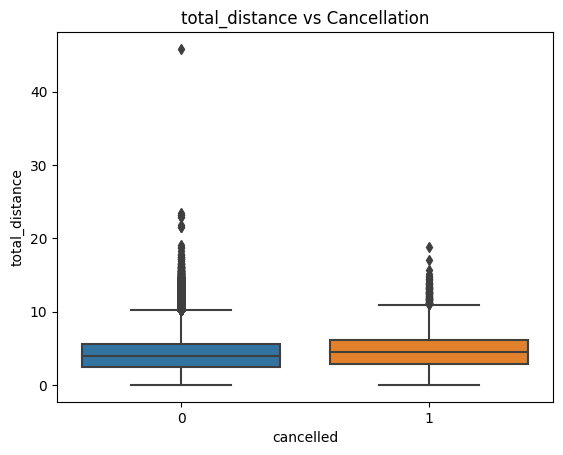

In [66]:
# Boxplot of time difference grouped by cancelled
sns.boxplot(x='cancelled', y='total_distance', data=rider_df)
plt.title("total_distance vs Cancellation")
plt.show()

### There is outliers

In [67]:
Q1 = rider_df['total_distance'].quantile(0.25)
Q3 = rider_df['total_distance'].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
rider_df = rider_df[(rider_df['total_distance'] >= lower_bound) & (rider_df['total_distance'] <= upper_bound)]

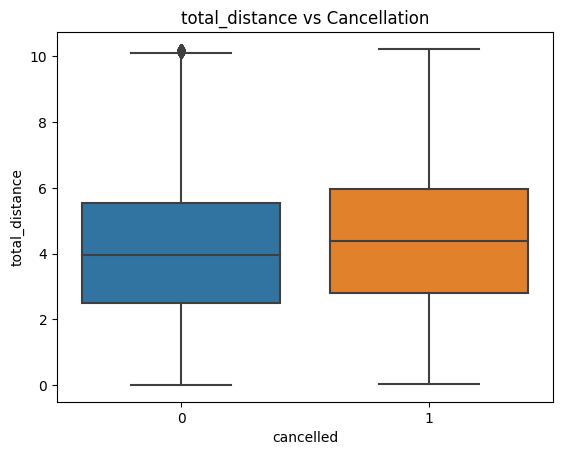

In [68]:
# After removed outliers
sns.boxplot(x='cancelled', y='total_distance', data=rider_df)
plt.title("total_distance vs Cancellation")
plt.show()

The boxplot shows that cancelled rides tend to have slightly higher total trip distances compared to non-cancelled rides, although the distributions overlap significantly.

In [69]:
rider_df[rider_df['cancelled']==1].info()


<class 'pandas.core.frame.DataFrame'>
Index: 5121 entries, 20 to 449960
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_time             5121 non-null   object        
 1   order_id               5121 non-null   int64         
 2   order_date             5121 non-null   object        
 3   allot_time             5121 non-null   datetime64[ns]
 4   accept_time            4968 non-null   datetime64[ns]
 5   pickup_time            2735 non-null   datetime64[ns]
 6   delivered_time         0 non-null      datetime64[ns]
 7   rider_id               5121 non-null   int64         
 8   first_mile_distance    5121 non-null   float64       
 9   last_mile_distance     5121 non-null   float64       
 10  alloted_orders         4483 non-null   float64       
 11  delivered_orders       4277 non-null   float64       
 12  cancelled              5121 non-null   int64         
 13  undel

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


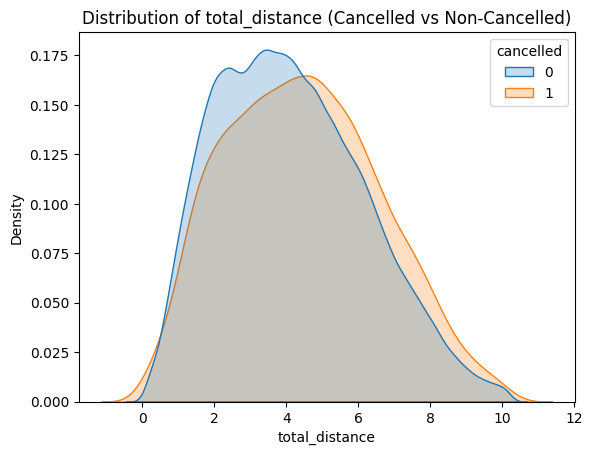

In [70]:
# Plot density directly
sns.kdeplot(data=rider_df, x='total_distance', hue='cancelled', fill=True, common_norm=False)
plt.title("Distribution of total_distance (Cancelled vs Non-Cancelled)")
plt.show()

The density plot shows that the distribution of total trip distance is very similar for cancelled and non-cancelled rides. Most rides occur between 2 and 6 km. Cancelled rides show a slightly higher concentration at larger distances, suggesting that longer trips may have a slightly higher chance of cancellation, although the difference is not very strong.

In [71]:
rider_df.undelivered_orders.describe()


count    428625.000000
mean          0.764036
std           1.066564
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           9.000000
Name: undelivered_orders, dtype: float64

In [72]:
rider_df[rider_df['cancelled']==1].undelivered_orders.describe()


count    4277.000000
mean        0.843114
std         1.145999
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         8.000000
Name: undelivered_orders, dtype: float64

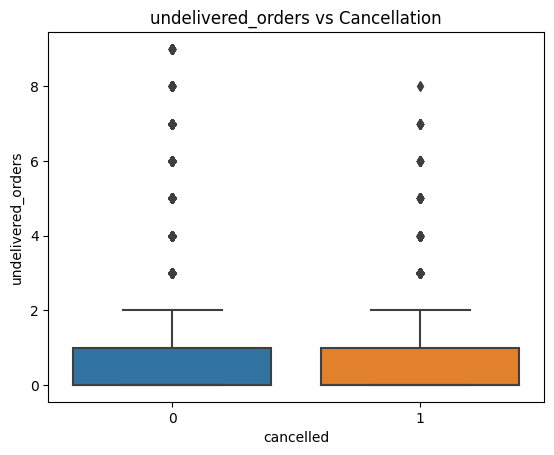

In [73]:
sns.boxplot(x='cancelled', y='undelivered_orders', data=rider_df)
plt.title("undelivered_orders vs Cancellation")
plt.show()

The boxplot shows that the distribution of undelivered orders is very similar for cancelled and non-cancelled rides. The median value is close to zero in both groups, indicating that most riders do not have undelivered orders. Although a few riders have higher numbers of undelivered orders, these appear as outliers and do not show a strong difference between the two groups.

In [74]:
rider_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 445850 entries, 0 to 449999
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_time             445850 non-null  object        
 1   order_id               445850 non-null  int64         
 2   order_date             445850 non-null  object        
 3   allot_time             445850 non-null  datetime64[ns]
 4   accept_time            445697 non-null  datetime64[ns]
 5   pickup_time            443464 non-null  datetime64[ns]
 6   delivered_time         440729 non-null  datetime64[ns]
 7   rider_id               445850 non-null  int64         
 8   first_mile_distance    445850 non-null  float64       
 9   last_mile_distance     445850 non-null  float64       
 10  alloted_orders         429018 non-null  float64       
 11  delivered_orders       428625 non-null  float64       
 12  cancelled              445850 non-null  int64    

In [75]:
rider_df.allot_time

0        2021-01-26 02:21:00
1        2021-01-26 02:33:00
2        2021-01-26 02:39:00
3        2021-01-26 02:48:00
4        2021-01-26 03:07:00
                 ...        
449995   2021-02-06 10:03:00
449996   2021-02-06 10:03:00
449997   2021-02-06 10:04:00
449998   2021-02-06 10:03:00
449999   2021-02-06 10:03:00
Name: allot_time, Length: 445850, dtype: datetime64[ns]

In [76]:
print(rider_df['allot_time'].dt.hour.unique())
print("Max hour:", rider_df['allot_time'].dt.hour.max())

[ 2  3  4  5  6  7  8  9 10 11 13 12 14 15 16 17 18 19 20 21  1  0]
Max hour: 21


rider alloted in maximum 21 hour

In [77]:
# print(rider_df['allot_time'].dt.hour)


In [78]:
# print(rider_df['allot_time'].dt.date)
# print(rider_df['allot_time'].dt.time)


In [79]:
rider_df['time_only'] = rider_df['allot_time'].dt.time

# Count orders for each time across all days
time_orders = rider_df['time_only'].value_counts()

In [80]:
time_orders

time_only
13:33:00    1846
13:32:00    1845
13:34:00    1725
13:31:00    1706
13:35:00    1508
            ... 
03:03:00       1
19:51:00       1
02:24:00       1
02:44:00       1
03:04:00       1
Name: count, Length: 1017, dtype: int64

In [81]:
def assign_time_slot(dt):
    hour=dt.hour
    start=(hour//2)*2 #floor to nearest multiple of 2
    end=start+2
    start_str = "{:02d}".format(start)
    end_str = "{:02d}".format(end)
    return "{}:00 - {}:00".format(start_str,end_str)

In [82]:
rider_df['time_slot'] = rider_df.time_only.apply(assign_time_slot)

In [83]:
rider_df['time_slot'].value_counts()

time_slot
14:00 - 16:00    135477
16:00 - 18:00    119675
08:00 - 10:00     59682
06:00 - 08:00     59404
12:00 - 14:00     51010
10:00 - 12:00     16809
04:00 - 06:00      2296
18:00 - 20:00       812
02:00 - 04:00       671
20:00 - 22:00        10
00:00 - 02:00         4
Name: count, dtype: int64

In [84]:
rider_df[rider_df.cancelled==1].time_slot.value_counts()

time_slot
14:00 - 16:00    1599
16:00 - 18:00    1518
08:00 - 10:00     648
12:00 - 14:00     518
06:00 - 08:00     517
10:00 - 12:00     229
18:00 - 20:00      55
04:00 - 06:00      30
02:00 - 04:00       6
20:00 - 22:00       1
Name: count, dtype: int64

From here we can see the most orders cancelled during 14:00 - 16:00 and 16:00 to 18:00

In [85]:
def peakhr(time):
    if time in ['14:00 - 16:00', '16:00 - 18:00']:
        return 1
    else :
        return 0

In [86]:
rider_df['peak_hour'] = rider_df.time_slot.apply(peakhr)

In [87]:
rider_df['peak_hour'].value_counts()

peak_hour
1    255152
0    190698
Name: count, dtype: int64

In [88]:
rider_df.groupby('peak_hour')['cancelled'].mean()

peak_hour
0    0.010509
1    0.012216
Name: cancelled, dtype: float64

The cancellation rate during peak hours (14:00–18:00) is slightly higher (1.23%) compared to non-peak hours (1.07%). This suggests that orders placed during peak hours have a marginally higher likelihood of cancellation, possibly due to increased demand or operational pressure.

In [89]:
rider_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 445850 entries, 0 to 449999
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_time             445850 non-null  object        
 1   order_id               445850 non-null  int64         
 2   order_date             445850 non-null  object        
 3   allot_time             445850 non-null  datetime64[ns]
 4   accept_time            445697 non-null  datetime64[ns]
 5   pickup_time            443464 non-null  datetime64[ns]
 6   delivered_time         440729 non-null  datetime64[ns]
 7   rider_id               445850 non-null  int64         
 8   first_mile_distance    445850 non-null  float64       
 9   last_mile_distance     445850 non-null  float64       
 10  alloted_orders         429018 non-null  float64       
 11  delivered_orders       428625 non-null  float64       
 12  cancelled              445850 non-null  int64    

In [90]:
rider_df.order_date = pd.to_datetime(rider_df.order_date)

/tmp/ipykernel_680/4083029579.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  rider_df.order_date = pd.to_datetime(rider_df.order_date)


In [91]:
rider_df.order_date.info()

<class 'pandas.core.series.Series'>
Index: 445850 entries, 0 to 449999
Series name: order_date
Non-Null Count   Dtype         
--------------   -----         
445850 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 6.8 MB


In [92]:
# Create new column with weekday name
rider_df['day_of_weeks'] = rider_df['order_date'].dt.day_name()

In [93]:
rider_df['day_of_weeks']

0          Tuesday
1          Tuesday
2          Tuesday
3          Tuesday
4          Tuesday
            ...   
449995    Saturday
449996    Saturday
449997    Saturday
449998    Saturday
449999    Saturday
Name: day_of_weeks, Length: 445850, dtype: object

In [94]:
rider_df[['order_date', 'day_of_weeks']].head()

,order_date,day_of_weeks
0,2021-01-26,Tuesday
1,2021-01-26,Tuesday
2,2021-01-26,Tuesday
3,2021-01-26,Tuesday
4,2021-01-26,Tuesday


In [95]:
rider_df.day_of_weeks.value_counts()


day_of_weeks
Friday       83012
Thursday     79859
Wednesday    79622
Tuesday      78152
Saturday     49028
Sunday       38724
Monday       37453
Name: count, dtype: int64

orders happens more on Friday,Thursday,wednesday and Tuesday

In [96]:
rider_df.head(5)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,order_time,order_id,order_date,allot_time,accept_time,pickup_time,delivered_time,rider_id,first_mile_distance,last_mile_distance,...,reassigned_order,session_time,cancelled_time,acceptallotdiff,acceptallotdiff_clean,total_distance,time_only,time_slot,peak_hour,day_of_weeks
0,26-01-2021 02:21,556753,2021-01-26,2021-01-26 02:21:00,2021-01-26 02:22:00,2021-01-26 02:32:00,2021-01-26 02:49:00,11696,1.5666,2.65,...,NaN,NaN,NaT,1.0,1.0,4.2166,02:21:00,02:00 - 04:00,0,Tuesday
1,26-01-2021 02:33,556754,2021-01-26,2021-01-26 02:33:00,2021-01-26 02:34:00,2021-01-26 02:50:00,2021-01-26 03:11:00,18117,2.5207,2.76,...,NaN,3.266667,NaT,1.0,1.0,5.2807,02:33:00,02:00 - 04:00,0,Tuesday
2,26-01-2021 02:39,556755,2021-01-26,2021-01-26 02:39:00,2021-01-26 02:40:00,2021-01-26 02:56:00,2021-01-26 03:12:00,18623,2.2074,4.80,...,NaN,9.816667,NaT,1.0,1.0,7.0074,02:39:00,02:00 - 04:00,0,Tuesday
3,26-01-2021 02:47,556756,2021-01-26,2021-01-26 02:48:00,2021-01-26 02:49:00,2021-01-26 03:21:00,2021-01-26 03:41:00,15945,2.1894,6.38,...,NaN,17.533333,NaT,1.0,1.0,8.5694,02:48:00,02:00 - 04:00,0,Tuesday
4,26-01-2021 03:06,556757,2021-01-26,2021-01-26 03:07:00,2021-01-26 03:07:00,2021-01-26 03:31:00,2021-01-26 04:00:00,17589,2.7870,4.01,...,NaN,1.350000,NaT,0.0,0.0,6.7970,03:07:00,02:00 - 04:00,0,Tuesday


In [99]:
# cat_cols = ['reassignment_method', 'reassignment_reason']

# # Apply one-hot encoding(dummy variable trap)
# rider_df_encoded = pd.get_dummies(rider_df, columns=cat_cols, drop_first=True)

In [100]:
# rider_df_encoded.info()